In [7]:
from langgraph.graph import StateGraph
from typing import Dict, Any, TypedDict, List
from IPython.display import display, Image

In [12]:
def clean_notes(state):
    state['cleaned_notes'] = " ".join(state["notes"].split())
    return state

def extract_action_items(state):
    sentences = state["cleaned_notes"].split(".")
    actions = []
    for s in sentences:
        if " will " in s:
            owner, task = s.split(" will ", 1)
            actions.append({"owner": owner.strip(), "task": task.strip()})
    state['action_items'] = actions
    return state

def final_format(state):
    state['final'] = state['action_items']
    return state

class NotesState(TypedDict):
    notes: str
    cleaned_notes: str
    action_items: List[Dict]
    final: List[Dict]

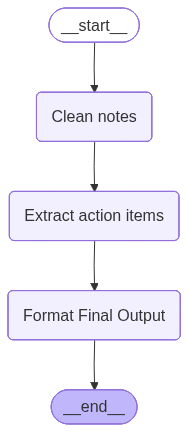

In [13]:
builder = StateGraph(NotesState)
builder.add_node('Clean notes', clean_notes)
builder.add_node('Extract action items', extract_action_items)
builder.add_node('Format Final Output', final_format)

builder.set_entry_point('Clean notes')
builder.add_edge('Clean notes','Extract action items')
builder.add_edge('Extract action items','Format Final Output')
builder.set_finish_point('Format Final Output')

graph = builder.compile()

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Visualization failed. Ensure Mermaid & pygraphviz dependencies are installed.")
    print(f"Error: {e}")

In [14]:
input_notes = {'notes':'''Today we discussed the new chatbot feature rollout. Raj said backend integration is almost done but needs 2 more days. 
UI team is waiting for API endpoints. Nivetha suggested adding a feedback form after chat ends. 
Arun will check the server logs and identify bottlenecks. Raj will finalize the API by Friday. UI team (Meena) will start integration once API is ready. 
Nivetha will draft the feedback form questions and share with the team by Wednesday.
Next meeting planned on Thursday 4 PM. Also, we need to update the client by end of this week about the progress.'''}
result = graph.invoke(input_notes)
print(result)

{'notes': 'Today we discussed the new chatbot feature rollout. Raj said backend integration is almost done but needs 2 more days. \nUI team is waiting for API endpoints. Nivetha suggested adding a feedback form after chat ends. \nArun will check the server logs and identify bottlenecks. Raj will finalize the API by Friday. UI team (Meena) will start integration once API is ready. \nNivetha will draft the feedback form questions and share with the team by Wednesday.\nNext meeting planned on Thursday 4 PM. Also, we need to update the client by end of this week about the progress.', 'cleaned_notes': 'Today we discussed the new chatbot feature rollout. Raj said backend integration is almost done but needs 2 more days. UI team is waiting for API endpoints. Nivetha suggested adding a feedback form after chat ends. Arun will check the server logs and identify bottlenecks. Raj will finalize the API by Friday. UI team (Meena) will start integration once API is ready. Nivetha will draft the feed

In [15]:
print(result['final'])

[{'owner': 'Arun', 'task': 'check the server logs and identify bottlenecks'}, {'owner': 'Raj', 'task': 'finalize the API by Friday'}, {'owner': 'UI team (Meena)', 'task': 'start integration once API is ready'}, {'owner': 'Nivetha', 'task': 'draft the feedback form questions and share with the team by Wednesday'}]
